# 🧠 Notebook 4: Model Training (Phase 1 — Tabular Only)

## LightGBM, XGBoost & Tabular Ensemble

**Phase 1 scope:** Train and validate **metadata-only** models using stratified **patient-grouped** cross-validation, then blend LightGBM and XGBoost out-of-fold predictions. **Images and multi-modal fusion are deferred to Phase 2.**

**Leakage controls (with Notebook 3):** Feature shortlists use a **grouped selection train split** only. **Site residual** features are built **per CV fold** from that fold's training rows. **Median imputation** is fit **per fold** on training rows only.

**Models (this notebook):**
1. **LightGBM** — Primary tabular model with `scale_pos_weight` for imbalance
2. **XGBoost** — Secondary model for ensemble diversity
3. **Weighted tabular ensemble** — Grid search over blend weights on OOF predictions

**Phase 2:** Image CNN + tabular fusion lives in **`06_Image_Training_and_Fusion.ipynb`** (same CV folds; does not re-run boosting here).

### Imbalance (no global balancing)

Use the **full** training fold with **loss reweighting** (`scale_pos_weight`). Optional **`CFG.majority_subsample_fraction < 1.0`** subsamples majority rows **inside each train fold** only (see `TrainingConfig`).

### Code layout

Shared helpers: `src/isic_challenge/`. This notebook adds `ROOT/src` to `sys.path`. Optional: `pip install -e .`

---


In [1]:
# ============================================================
# Setup (Phase 1 — tabular; no PyTorch required)
# ============================================================
import os, sys, warnings, gc, pickle, time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12})

def log_run(msg: str) -> None:
    """Timestamped line for long-running training (readable in Colab logs)."""
    ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print(f'[{ts}] {msg}', flush=True)

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/Skin-Cancer-Detection-ISIC-2024-'
else:
    ROOT = os.getcwd()

_SRC = os.path.abspath(os.path.join(ROOT, 'src'))
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)

from isic_challenge.config import TrainingConfig

CFG = TrainingConfig()
SEED = CFG.seed
np.random.seed(SEED)

_paths = CFG.paths(ROOT)
FIG_DIR = _paths['fig_dir']
MODEL_DIR = _paths['model_dir']
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

log_run(f'Project ROOT: {ROOT}')
log_run(f'Phase 1 (tabular) | TrainingConfig: n_folds={CFG.n_folds}, majority_subsample_fraction={CFG.majority_subsample_fraction}')


[2026-03-22 15:33:25] Project ROOT: /Users/mahi0606/Desktop/Skin-Cancer-Detection-ISIC-2024-
[2026-03-22 15:33:25] Phase 1 (tabular) | TrainingConfig: n_folds=5, majority_subsample_fraction=1.0


In [2]:
# ============================================================
# Load Preprocessed Data (from Notebook 3)
# ============================================================
prep_path = CFG.paths(ROOT)['prep_pickle']

from sklearn.impute import SimpleImputer
from isic_challenge.cv_utils import site_residual_matrix, fold_impute_median


if os.path.exists(prep_path):
    with open(prep_path, 'rb') as f:
        prep_data = pickle.load(f)
    X = prep_data['X']
    y = prep_data['y']
    groups = prep_data['groups']
    feature_cols = list(prep_data['feature_cols'])
    df_feat = prep_data['df_feat']
    SITE_RESID_NAMES = list(prep_data.get(
        'site_residual_cols',
        ['feat_areaMM2_vs_site', 'feat_color_std_mean_vs_site', 'feat_eccentricity_vs_site'],
    ))
    SITE_RAW_COLS = list(prep_data.get(
        'site_raw_cols',
        ['tbp_lv_areaMM2', 'tbp_lv_color_std_mean', 'tbp_lv_eccentricity'],
    ))
    feature_cols = [c for c in feature_cols if c not in SITE_RESID_NAMES]
    USE_SITE_RESIDUALS = (
        len(SITE_RAW_COLS) == len(SITE_RESID_NAMES) > 0
        and all(c in df_feat.columns for c in SITE_RAW_COLS)
        and 'anatom_site_general' in df_feat.columns
    )
    if not USE_SITE_RESIDUALS:
        SITE_RAW_COLS = []
        SITE_RESID_NAMES = []
    MODEL_FEATURE_COLS = list(feature_cols) + list(SITE_RESID_NAMES)

    print(f"✅ Loaded preprocessed data: X={X.shape}, y={y.shape}")
    print(f"   Positive samples: {y.sum()}")
    print(f"   Tabular columns in X: {len(feature_cols)}")
    if prep_data.get('imputer_per_fold', True):
        print("   Imputation: median, fit per CV fold (no validation leakage)")
    if USE_SITE_RESIDUALS:
        print(f"   Site residual features (per fold): {SITE_RESID_NAMES}")
    print(f"   Model input width: {len(MODEL_FEATURE_COLS)}")
else:
    print("⚠️  preprocessed_data.pkl not found!")
    print("   Please run Notebook 03_Feature_Engineering.ipynb first.")
    print("   Re-running feature engineering inline...")

    DATA_DIR = os.path.join(ROOT, 'ISIC 2024 Skin Cancer Challenge Dataset')
    df = pd.read_csv(os.path.join(DATA_DIR, 'train-metadata.csv'), low_memory=False)
    print(f"   Loaded {len(df):,} samples")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c != 'target']
    X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(df[feature_cols]),
                     columns=feature_cols)
    X = X.replace([np.inf, -np.inf], 0).fillna(0)
    y = df['target'].values
    groups = df['patient_id'].values
    df_feat = df
    SITE_RAW_COLS = []
    SITE_RESID_NAMES = []
    USE_SITE_RESIDUALS = False
    MODEL_FEATURE_COLS = list(feature_cols)
    print(f"   Prepared: X={X.shape}, y={y.shape}")



✅ Loaded preprocessed data: X=(401059, 70), y=(401059,)
   Positive samples: 393
   Tabular columns in X: 70
   Imputation: median, fit per CV fold (no validation leakage)
   Site residual features (per fold): ['feat_areaMM2_vs_site', 'feat_color_std_mean_vs_site', 'feat_eccentricity_vs_site']
   Model input width: 73


## 4.1 Custom Metrics

The ISIC 2024 **primary leaderboard metric** is **partial AUC (pAUC) above 88% true positive rate (TPR)** for classifying malignant lesions. The challenge focuses on the ROC region where sensitivity is already high (see [ISIC Challenge 2024 Metrics](https://github.com/ISIC-Research/Challenge-2024-Metrics)). On the official scale, scores typically fall in a **narrow range near [0, 0.12]**—not on **[0, 1]** like full ROC-AUC—so treat pAUC as **comparable across models**, not as a second “AUC” on the same scale as ROC-AUC.

`compute_pauc` below follows the reference `PrimaryMetric-pAUC.py` (label inversion + partial integration up to **FPR = 1 − min_tpr**).


In [3]:
# ============================================================
# 4.1 — Custom Metric Functions (competition-aligned)
# ============================================================
from isic_challenge.metrics import compute_pauc, compute_all_metrics

# Quick test
test_y = np.array([0] * 100 + [1] * 5)
test_p = np.concatenate([np.random.uniform(0, 0.3, 100), np.random.uniform(0.5, 1.0, 5)])
test_metrics = compute_all_metrics(test_y, test_p)
print("Metric functions test:")
for k, v in test_metrics.items():
    s = f"{v:.6f}" if np.isfinite(v) else str(v)
    print(f"  {k}: {s}")
print("✅ Metrics OK")


Metric functions test:
  ROC-AUC: 1.000000
  pAUC (≥88% TPR, ISIC 24): 0.120000
  Average Precision: 1.000000
  Precision: 1.000000
  Recall (Sensitivity): 1.000000
  F1: 1.000000
✅ Metrics OK


## 4.2 LightGBM Training with Cross-Validation

**Why LightGBM?**
- Gradient-boosted decision trees are **optimal for tabular data** (Grinsztajn et al., 2022)
- Handles missing values natively
- Fast training, efficient with large datasets
- `scale_pos_weight` directly addresses class imbalance
- Built-in feature importance for interpretability

In [4]:
# ============================================================
# 4.2 — LightGBM with StratifiedGroupKFold
# ============================================================
from isic_challenge.cv_utils import subsample_majority_train_indices

N_FOLDS = CFG.n_folds
IMBALANCE_RATIO = (y == 0).sum() / max((y == 1).sum(), 1)

lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': CFG.lgb_learning_rate,
    'num_leaves': CFG.lgb_num_leaves,
    'max_depth': CFG.lgb_max_depth,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'scale_pos_weight': IMBALANCE_RATIO,
    'random_state': SEED,
    'n_jobs': -1,
}

log_run('LightGBM: starting CV setup')
print(f"LightGBM Configuration:")
print(f"  Folds: {N_FOLDS}")
print(f"  Imbalance ratio (scale_pos_weight): {IMBALANCE_RATIO:.1f}")
print(f"  Base tabular features: {X.shape[1]}")
print(f"  Model features (with fold-wise site residuals): {len(MODEL_FEATURE_COLS)}")
print(f"  Samples: {X.shape[0]:,}")
print(f"  Median imputation: fit on train fold each split")
if CFG.majority_subsample_fraction < 1.0:
    print(f"  Majority subsample (train rows only per fold): {CFG.majority_subsample_fraction:.2%} of negatives")

try:
    cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_iterator = list(cv.split(X, y, groups=groups))
    cv_type = "StratifiedGroupKFold (by patient_id)"
except Exception:
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_iterator = list(cv.split(X, y))
    cv_type = "StratifiedKFold (fallback)"

print(f"  CV strategy: {cv_type}")
log_run(f'LightGBM: training {N_FOLDS} folds (boosting logs every {CFG.boost_log_interval} rounds)')

lgb_oof_preds = np.zeros(len(y))
lgb_models = []
lgb_fold_scores = []
lgb_feature_importances = np.zeros(len(MODEL_FEATURE_COLS))

fold_pbar = tqdm(list(enumerate(fold_iterator)), total=N_FOLDS, desc='LightGBM CV', unit='fold')
for fold, (train_idx, val_idx) in fold_pbar:
    t0 = time.time()
    fold_pbar.set_postfix_str(f'prep fold {fold + 1}')

    rng = np.random.default_rng(CFG.seed + fold)
    train_idx_fit = subsample_majority_train_indices(train_idx, y, CFG.majority_subsample_fraction, rng)
    if len(train_idx_fit) < len(train_idx):
        log_run(f'LightGBM fold {fold + 1}: training on {len(train_idx_fit):,} / {len(train_idx):,} train rows (majority subsample)')

    if USE_SITE_RESIDUALS:
        SRM = site_residual_matrix(df_feat, train_idx_fit, SITE_RAW_COLS)
        X_fd = X.copy()
        for j, name in enumerate(SITE_RESID_NAMES):
            X_fd[name] = SRM[:, j]
    else:
        X_fd = X.copy()
    X_fd = fold_impute_median(X_fd, train_idx_fit)

    X_train, X_val = X_fd.iloc[train_idx_fit], X_fd.iloc[val_idx]
    y_train, y_val = y[train_idx_fit], y[val_idx]

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    fold_pbar.set_postfix_str(f'fold {fold + 1}: boosting…')
    model = lgb.train(
        lgbm_params,
        train_data,
        num_boost_round=CFG.boost_n_estimators,
        valid_sets=[val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=CFG.boost_early_stopping_rounds, verbose=False),
            lgb.log_evaluation(period=CFG.boost_log_interval),
        ]
    )

    val_preds = model.predict(X_val)
    lgb_oof_preds[val_idx] = val_preds

    fold_auc = roc_auc_score(y_val, val_preds)
    fold_pauc = compute_pauc(y_val, val_preds)
    lgb_fold_scores.append({'fold': fold, 'auc': fold_auc, 'pauc': fold_pauc,
                            'n_train': len(train_idx_fit), 'n_val': len(val_idx),
                            'pos_val': y_val.sum(), 'best_iter': model.best_iteration})
    lgb_models.append(model)
    lgb_feature_importances += model.feature_importance(importance_type='gain')

    elapsed = time.time() - t0
    fold_pbar.set_postfix_str(f'AUC={fold_auc:.4f} | {elapsed:.0f}s')
    log_run(f'LightGBM fold {fold + 1}/{N_FOLDS} done: val AUC={fold_auc:.4f}, pAUC={fold_pauc:.4f}, '
            f'best_iter={model.best_iteration}, wall={elapsed:.1f}s')

fold_pbar.close()
lgb_feature_importances /= N_FOLDS

print(f"\n{'='*60}")
oof_auc = roc_auc_score(y, lgb_oof_preds)
oof_pauc = compute_pauc(y, lgb_oof_preds)
log_run(f'LightGBM OOF complete: ROC-AUC={oof_auc:.4f}, pAUC={oof_pauc:.4f}')
print(f"LightGBM OOF Results:")
print(f"  ROC-AUC: {oof_auc:.4f}")
print(f"  pAUC (≥88% TPR, ISIC): {oof_pauc:.4f}")
print(f"  Mean fold AUC: {np.mean([s['auc'] for s in lgb_fold_scores]):.4f} ± {np.std([s['auc'] for s in lgb_fold_scores]):.4f}")


[2026-03-22 15:33:26] LightGBM: starting CV setup
LightGBM Configuration:
  Folds: 5
  Imbalance ratio (scale_pos_weight): 1019.5
  Base tabular features: 70
  Model features (with fold-wise site residuals): 73
  Samples: 401,059
  Median imputation: fit on train fold each split
  CV strategy: StratifiedGroupKFold (by patient_id)
[2026-03-22 15:33:27] LightGBM: training 5 folds (boosting logs every 100 rounds)


LightGBM CV:   0%|          | 0/5 [00:00<?, ?fold/s]

[100]	valid_0's auc: 0.616871
[2026-03-22 15:33:33] LightGBM fold 1/5 done: val AUC=0.8890, pAUC=0.0551, best_iter=1, wall=6.5s
[100]	valid_0's auc: 0.525673
[2026-03-22 15:33:39] LightGBM fold 2/5 done: val AUC=0.8646, pAUC=0.0572, best_iter=1, wall=6.3s
[100]	valid_0's auc: 0.671433
[2026-03-22 15:33:45] LightGBM fold 3/5 done: val AUC=0.7467, pAUC=0.0140, best_iter=1, wall=5.7s
[100]	valid_0's auc: 0.531536
[2026-03-22 15:33:51] LightGBM fold 4/5 done: val AUC=0.8041, pAUC=0.0142, best_iter=1, wall=5.4s
[100]	valid_0's auc: 0.652126
[2026-03-22 15:33:56] LightGBM fold 5/5 done: val AUC=0.8095, pAUC=0.0154, best_iter=1, wall=5.6s

[2026-03-22 15:33:56] LightGBM OOF complete: ROC-AUC=0.8207, pAUC=0.0297
LightGBM OOF Results:
  ROC-AUC: 0.8207
  pAUC (≥88% TPR, ISIC): 0.0297
  Mean fold AUC: 0.8228 ± 0.0499


## 4.3 XGBoost Training

XGBoost provides **ensemble diversity** — its regularization and optimization differs from 
LightGBM (level-wise vs leaf-wise growth), producing complementary predictions.

In [5]:
# ============================================================
# 4.3 — XGBoost with Same CV Splits
# ============================================================
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': CFG.lgb_max_depth,
    'learning_rate': CFG.lgb_learning_rate,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': IMBALANCE_RATIO,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': -1,
    'tree_method': 'hist',
}

log_run('XGBoost: starting CV (same splits as LightGBM)')
xgb_oof_preds = np.zeros(len(y))
xgb_models = []
xgb_fold_scores = []

fold_pbar = tqdm(list(enumerate(fold_iterator)), total=N_FOLDS, desc='XGBoost CV', unit='fold')
for fold, (train_idx, val_idx) in fold_pbar:
    t0 = time.time()
    fold_pbar.set_postfix_str(f'prep fold {fold + 1}')

    rng = np.random.default_rng(CFG.seed + fold)
    train_idx_fit = subsample_majority_train_indices(train_idx, y, CFG.majority_subsample_fraction, rng)

    if USE_SITE_RESIDUALS:
        SRM = site_residual_matrix(df_feat, train_idx_fit, SITE_RAW_COLS)
        X_fd = X.copy()
        for j, name in enumerate(SITE_RESID_NAMES):
            X_fd[name] = SRM[:, j]
    else:
        X_fd = X.copy()
    X_fd = fold_impute_median(X_fd, train_idx_fit)

    X_train, X_val = X_fd.iloc[train_idx_fit], X_fd.iloc[val_idx]
    y_train, y_val = y[train_idx_fit], y[val_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    fold_pbar.set_postfix_str(f'fold {fold + 1}: boosting…')
    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=CFG.boost_n_estimators,
        evals=[(dval, 'val')],
        early_stopping_rounds=CFG.boost_early_stopping_rounds,
        verbose_eval=CFG.boost_log_interval,
    )

    val_preds = model.predict(dval)
    xgb_oof_preds[val_idx] = val_preds

    fold_auc = roc_auc_score(y_val, val_preds)
    fold_pauc = compute_pauc(y_val, val_preds)
    xgb_fold_scores.append({'fold': fold, 'auc': fold_auc, 'pauc': fold_pauc})
    xgb_models.append(model)

    elapsed = time.time() - t0
    fold_pbar.set_postfix_str(f'AUC={fold_auc:.4f} | {elapsed:.0f}s')
    log_run(f'XGBoost fold {fold + 1}/{N_FOLDS} done: val AUC={fold_auc:.4f}, pAUC={fold_pauc:.4f}, wall={elapsed:.1f}s')

fold_pbar.close()

oof_auc_xgb = roc_auc_score(y, xgb_oof_preds)
oof_pauc_xgb = compute_pauc(y, xgb_oof_preds)
log_run(f'XGBoost OOF complete: ROC-AUC={oof_auc_xgb:.4f}, pAUC={oof_pauc_xgb:.4f}')
print(f"\nXGBoost OOF:  AUC={oof_auc_xgb:.4f}, pAUC={oof_pauc_xgb:.4f}")


[2026-03-22 15:33:56] XGBoost: starting CV (same splits as LightGBM)


XGBoost CV:   0%|          | 0/5 [00:00<?, ?fold/s]

[0]	val-auc:0.84033
[100]	val-auc:0.94259
[160]	val-auc:0.94316
[2026-03-22 15:34:04] XGBoost fold 1/5 done: val AUC=0.9432, pAUC=0.0913, wall=7.6s
[0]	val-auc:0.67941
[100]	val-auc:0.92573
[200]	val-auc:0.91872
[202]	val-auc:0.91838
[2026-03-22 15:34:15] XGBoost fold 2/5 done: val AUC=0.9184, pAUC=0.0683, wall=10.7s
[0]	val-auc:0.68622
[100]	val-auc:0.94658
[184]	val-auc:0.93948
[2026-03-22 15:34:25] XGBoost fold 3/5 done: val AUC=0.9395, pAUC=0.0831, wall=10.4s
[0]	val-auc:0.69426
[100]	val-auc:0.93073
[200]	val-auc:0.93949
[293]	val-auc:0.93129
[2026-03-22 15:34:37] XGBoost fold 4/5 done: val AUC=0.9313, pAUC=0.0800, wall=11.9s
[0]	val-auc:0.77495
[100]	val-auc:0.93073
[200]	val-auc:0.91504
[205]	val-auc:0.91274
[2026-03-22 15:34:46] XGBoost fold 5/5 done: val AUC=0.9127, pAUC=0.0659, wall=9.4s
[2026-03-22 15:34:46] XGBoost OOF complete: ROC-AUC=0.9147, pAUC=0.0655

XGBoost OOF:  AUC=0.9147, pAUC=0.0655


## 4.4 Feature Importance Analysis

Understanding which features drive predictions is critical for:
1. **Interpretability** — can we explain decisions to clinicians?
2. **Feature selection** — can we simplify the model?
3. **Clinical insight** — what makes a lesion suspicious?

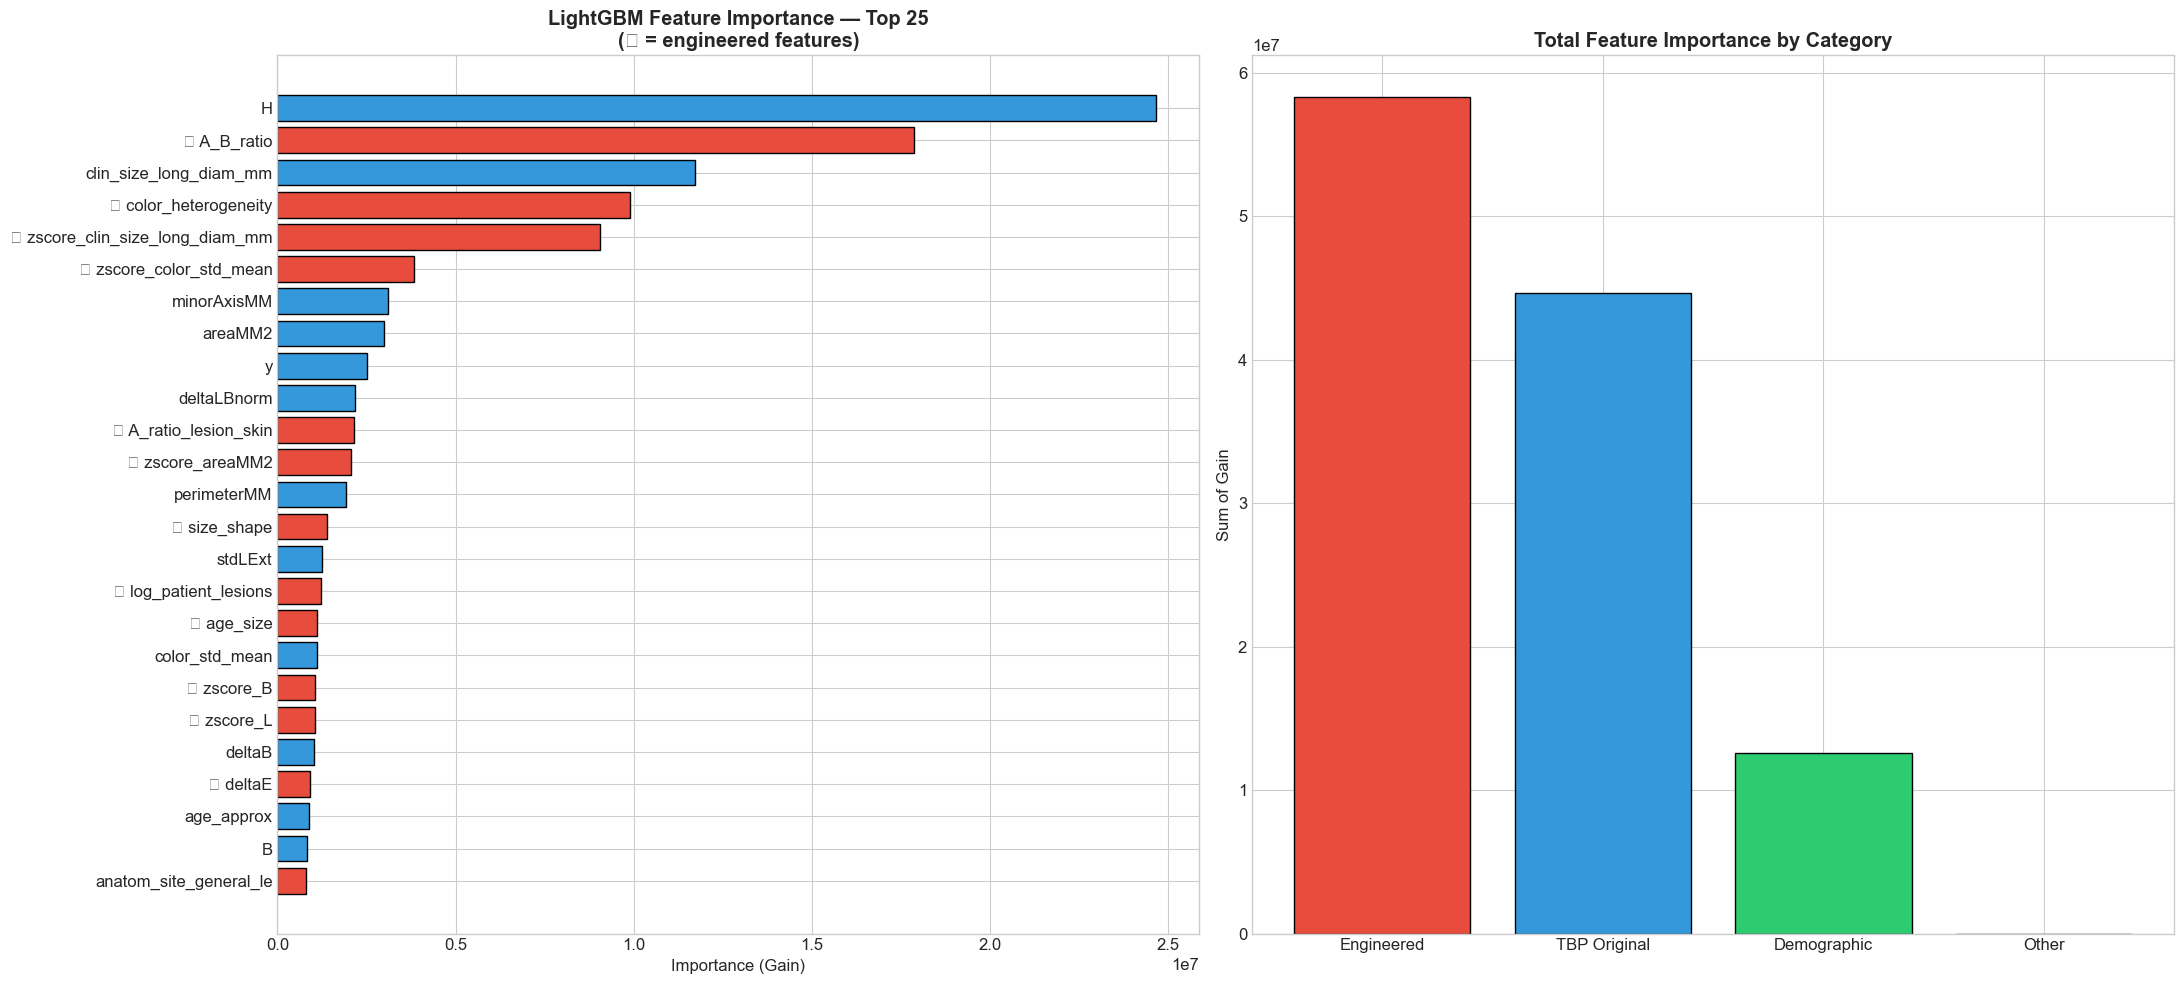


📌 Engineered features in top-25: 13


In [6]:
# ============================================================
# 4.4 — Feature Importance (LightGBM)
# ============================================================
fi_df = pd.DataFrame({
    'Feature': MODEL_FEATURE_COLS,
    'Importance': lgb_feature_importances
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

top25 = fi_df.head(25)
bar_colors = ['#e74c3c' if f.startswith('feat_') or f.endswith('_encoded') or f.endswith('_le')
              else '#3498db' for f in top25['Feature']]
axes[0].barh(range(len(top25)), top25['Importance'].values, color=bar_colors, edgecolor='black')
axes[0].set_yticks(range(len(top25)))
axes[0].set_yticklabels([f.replace('tbp_lv_', '').replace('feat_', '⭐ ') for f in top25['Feature']])
axes[0].set_xlabel('Importance (Gain)')
axes[0].set_title('LightGBM Feature Importance — Top 25\n(⭐ = engineered features)', fontweight='bold')
axes[0].invert_yaxis()

categories = {'Engineered': [], 'TBP Original': [], 'Demographic': [], 'Other': []}
for _, row in fi_df.iterrows():
    f = row['Feature']
    imp = row['Importance']
    if f.startswith('feat_') or f.endswith('_encoded') or f.endswith('_le'):
        categories['Engineered'].append(imp)
    elif f.startswith('tbp_lv_'):
        categories['TBP Original'].append(imp)
    elif f in ['age_approx', 'clin_size_long_diam_mm']:
        categories['Demographic'].append(imp)
    else:
        categories['Other'].append(imp)

cat_sums = {k: sum(v) for k, v in categories.items()}
axes[1].bar(cat_sums.keys(), cat_sums.values(),
           color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'], edgecolor='black')
axes[1].set_title('Total Feature Importance by Category', fontweight='bold')
axes[1].set_ylabel('Sum of Gain')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '12_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

n_eng_top25 = sum(1 for f in top25['Feature'] if f.startswith('feat_') or f.endswith('_encoded') or f.endswith('_le'))
print(f"\n📌 Engineered features in top-25: {n_eng_top25}")


## 4.5 Tabular ensemble (LightGBM + XGBoost)

**Phase 1 final scores** use a **late fusion** of the two tree models only: grid search over blend weights on **out-of-fold** predictions (no leakage). Phase 2 will add image logits and re-optimize weights.


In [7]:
# ============================================================
# 4.5 — Tabular ensemble: LightGBM + XGBoost (OOF blend)
# ============================================================
log_run('Ensemble: grid search LightGBM vs XGBoost weights on OOF preds')

best_auc_ens = 0
best_w_lgb = 0.5
weight_grid = np.arange(0.0, 1.01, 0.05)

for w in tqdm(weight_grid, desc='Tabular blend (LGB↔XGB)', unit='w'):
    ens_preds = w * lgb_oof_preds + (1 - w) * xgb_oof_preds
    auc = roc_auc_score(y, ens_preds)
    if auc > best_auc_ens:
        best_auc_ens = auc
        best_w_lgb = w

tabular_oof = best_w_lgb * lgb_oof_preds + (1 - best_w_lgb) * xgb_oof_preds
tabular_auc = roc_auc_score(y, tabular_oof)
tabular_pauc = compute_pauc(y, tabular_oof)

final_oof = tabular_oof
final_auc = tabular_auc
final_pauc = tabular_pauc

log_run(f'Tabular ensemble: best_w_lgb={best_w_lgb:.2f}, OOF AUC={tabular_auc:.4f}, pAUC={tabular_pauc:.4f}')
print(f"\nOptimal weights: LightGBM={best_w_lgb:.2f}, XGBoost={1 - best_w_lgb:.2f}")
print(f'Tabular ensemble OOF: AUC={tabular_auc:.4f}, pAUC={tabular_pauc:.4f}')
print('Phase 1 final predictions: final_oof == tabular_oof (image fusion in Phase 2).')


[2026-03-22 15:34:47] Ensemble: grid search LightGBM vs XGBoost weights on OOF preds


Tabular blend (LGB↔XGB):   0%|          | 0/21 [00:00<?, ?w/s]

[2026-03-22 15:34:49] Tabular ensemble: best_w_lgb=0.05, OOF AUC=0.9168, pAUC=0.0675

Optimal weights: LightGBM=0.05, XGBoost=0.95
Tabular ensemble OOF: AUC=0.9168, pAUC=0.0675
Phase 1 final predictions: final_oof == tabular_oof (image fusion in Phase 2).


[2026-03-22 15:34:49] Building results table and figures

MODEL COMPARISON (Out-of-Fold) — Phase 1 tabular
                       AUC      pAUC
Model                               
LightGBM          0.820736  0.029731
XGBoost           0.914656  0.065504
Tabular Ensemble  0.916800  0.067533


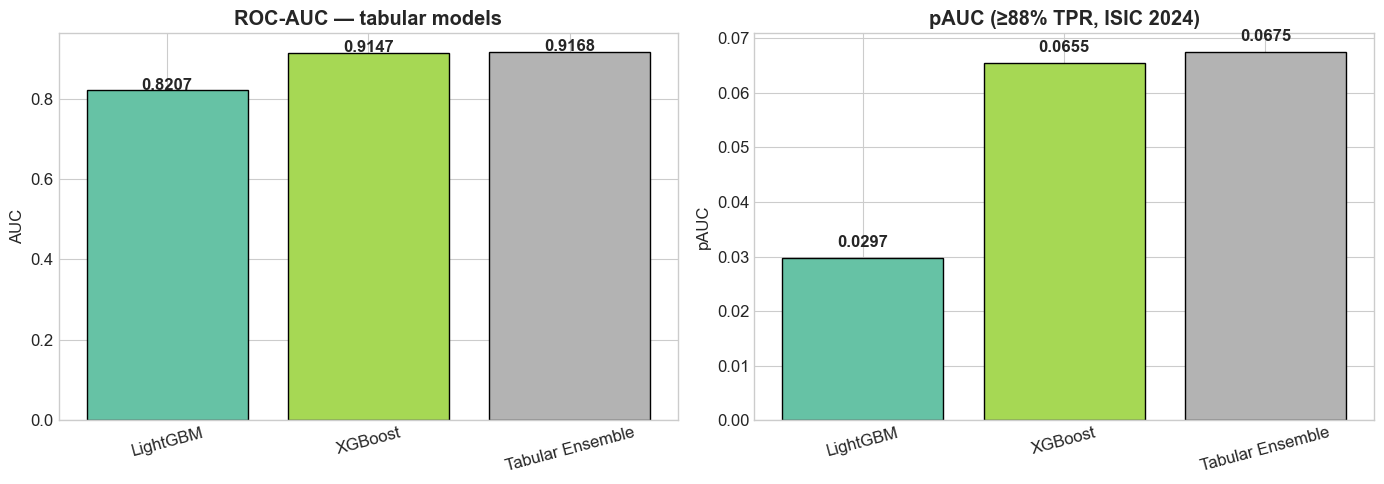

[2026-03-22 15:34:49] Writing outputs/model_predictions.pkl

✅ Saved model predictions to outputs/model_predictions.pkl (Phase 1 tabular)


In [8]:
# ============================================================
# 4.6 — Results comparison & save artifacts (Phase 1)
# ============================================================
results = {
    'LightGBM': {'AUC': roc_auc_score(y, lgb_oof_preds),
                 'pAUC': compute_pauc(y, lgb_oof_preds)},
    'XGBoost': {'AUC': roc_auc_score(y, xgb_oof_preds),
                'pAUC': compute_pauc(y, xgb_oof_preds)},
    'Tabular Ensemble': {'AUC': tabular_auc, 'pAUC': tabular_pauc},
}

log_run('Building results table and figures')
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

print("\n" + "=" * 60)
print('MODEL COMPARISON (Out-of-Fold) — Phase 1 tabular')
print("=" * 60)
print(results_df.to_string())

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(results_df))
colors_bar = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

axes[0].bar(x, results_df['AUC'], color=colors_bar, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df.index, rotation=15)
axes[0].set_title('ROC-AUC — tabular models', fontweight='bold')
axes[0].set_ylabel('AUC')
for i, v in enumerate(results_df['AUC']):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(x, results_df['pAUC'], color=colors_bar, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df.index, rotation=15)
axes[1].set_title('pAUC (≥88% TPR, ISIC 2024)', fontweight='bold')
axes[1].set_ylabel('pAUC')
for i, v in enumerate(results_df['pAUC']):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '13_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

pred_data = {
    'y': y,
    'lgb_oof': lgb_oof_preds,
    'xgb_oof': xgb_oof_preds,
    'tabular_oof': tabular_oof,
    'final_oof': final_oof,
    'phase': 'tabular_phase1',
    'has_img': False,
    'img_oof': None,
    'results_df': results_df,
    'feature_cols': MODEL_FEATURE_COLS,
    'feature_cols_tabular': feature_cols,
    'lgb_feature_importances': lgb_feature_importances,
    'df_feat': df_feat,
    'fold_iterator': fold_iterator,
}
log_run('Writing outputs/model_predictions.pkl')
with open(os.path.join(ROOT, 'outputs', 'model_predictions.pkl'), 'wb') as f:
    pickle.dump(pred_data, f)
print("\n✅ Saved model predictions to outputs/model_predictions.pkl (Phase 1 tabular)")


---

**Next:** For **Phase 2** (images + fusion), run **`06_Image_Training_and_Fusion.ipynb`** after this notebook (requires `pip install -e ".[image]"` and Kaggle image folder). Then **`05_Evaluation_and_Analysis.ipynb`** — ROC/pAUC, thresholding, and failure analysis using **`final_oof`** (tabular ensemble, or fused predictions after Notebook 6).
